In [16]:
from src.split_cluster import *

# 聚类的原理展示
常用的聚类算法包括k-means, spectral clustering等，他们可以根据一个元素均为**正数**的相关度矩阵将节点分为指定数量的类别。

在QUBO问题中，二进制变量间的相关度矩阵包含正数和负数。相关度矩阵的绝对值不会随着局部最优解的取值变化，但是正负性会。
需要找到一种新的聚类算法，能够处理可正可负的相关度矩阵。


In [17]:
n_clusters = 4  # Number of clusters
n_samples_per_cluster = 50  # Number of samples per cluster
n_features = 2  # Number of features
q_tilde = generate_affinity_matrix_with_negative(n_clusters, n_samples_per_cluster, n_features)
q_tilde.shape

(200, 200)

In [18]:
# 测试spectral clustering在正相关矩阵上的性能
S = np.abs(q_tilde)
D = np.diag(np.sum(S, axis=1))
L = D - S
eigvals, eigvecs = eigh(L, D)
# print(eigvals)
feature = eigvecs[:, np.argsort(eigvals)[:n_clusters*2]]
constrained_kmeans(feature, 60, 0, n_clusters)

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

In [19]:
# 测试kmeans constrained在正相关矩阵上的性能
kmeans = KMeansConstrained(
        n_clusters=n_clusters,
        size_max=60,
        size_min=0,
    )
kmeans.fit_predict(np.abs(q_tilde))

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

In [20]:
# 测试对于有正有负的相关矩阵，split_spectral_cluster的效果
q_tilde = generate_affinity_matrix_with_negative(n_clusters, n_samples_per_cluster, n_features)
split_spectral_cluster(q_tilde, 60, 40, 4)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 1, 3, 1, 3,
       2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3,
       2, 2, 1, 2, 3, 2, 3, 2, 3, 3, 3, 2, 3, 2, 3, 3, 2, 1, 2, 2, 2, 2,
       1, 3, 2, 3, 2, 2, 3, 1, 2, 3, 3, 2, 2, 2, 3, 2, 2, 3, 3, 3, 2, 2,
       3, 2, 3, 1, 3, 2, 3, 1, 2, 2, 1, 2, 2, 1, 3, 2, 2, 3, 3, 0, 0, 3,
       0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 3,
       0, 0], dtype=int32)

# Multi-view spectral clustering

In [21]:
from src.hybrid_qubo import *
from src.split_cluster import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## data generation

In [268]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import rbf_kernel

def synthetic_data_1(number_of_data_points_per_view: int) -> np.ndarray:
    """
    Generates a synthetic data set in manner of [#2]_.

    References
    ----------
    .. [#2] Abhishek Kumar, Piyush Rai, and Hal Daumé. 2011. Co-regularized multi-view spectral
        clustering. In Proceedings of the 24th International Conference on Neural Information Processing Systems (
        NIPS'11). Curran Associates Inc., Red Hook, NY, USA, 1413–1421.

    Parameters
    ----------
    number_of_data_points_per_view

    Returns
    -------

    view_1

    view_2

    correct_labels

    """

    n_clusters = 2

    means_view_1 = [(1, 1), (2, 2)]
    covariance_matrices_view_1 = [
        [[1, 0.5], [0.5, 1.5]],
        [[0.3, 0], [0, 0.6]]
    ]

    data_view_1_cluster_1 = np.random.multivariate_normal(means_view_1[0],
                                                          covariance_matrices_view_1[0],
                                                          int(number_of_data_points_per_view / n_clusters))

    data_view_1_cluster_2 = np.random.multivariate_normal(means_view_1[1],
                                                          covariance_matrices_view_1[1],
                                                          int(number_of_data_points_per_view / n_clusters))

    data = []
    for data_point in data_view_1_cluster_1:
        data.append([data_point[0], data_point[1], 0, 1])

    for data_point in data_view_1_cluster_2:
        data.append([data_point[0], data_point[1], 1, 1])

    means_view_2 = [(2, 2), (1, 1)]
    covariance_matrices_view_2 = [
        [[0.3, 0], [0, 0.6]],
        [[1, 0.5], [0.5, 1.5]]
    ]

    data_view_2_cluster_1 = np.random.multivariate_normal(means_view_2[0],
                                                          covariance_matrices_view_2[0],
                                                          int(number_of_data_points_per_view / n_clusters))

    data_view_2_cluster_2 = np.random.multivariate_normal(means_view_2[1],
                                                          covariance_matrices_view_2[1],
                                                          int(number_of_data_points_per_view / n_clusters))

    for data_point in data_view_2_cluster_1:
        data.append([data_point[0], data_point[1], 0, 2])

    for data_point in data_view_2_cluster_2:
        data.append([data_point[0], data_point[1], 1, 2])

    df = pd.DataFrame(data=data, columns=['x', 'y', 'cluster', 'view'])

    view_1 = df.loc[df['view'] == 1][['x', 'y']].values
    view_2 = df.loc[df['view'] == 2][['x', 'y']].values

    correct_labels = df.loc[df['view'] == 1]['cluster'].values

    return view_1, view_2, correct_labels

from scipy.spatial.distance import pdist, squareform
def adjacency_matrix(dataset: np.ndarray, metric: str) -> np.ndarray:
    """
    Calculates the pairwise distances of the row vectors of X. Returns an adjacency or distance matrix.

    Parameters
    ----------
    dataset : array-like, shape (number_of_data_objects, number_of_features)

    metric: str
        String value of a metric. Examples: ‘cityblock’, ‘cosine’, ‘euclidean’, ‘l1’, ‘l2’, ‘manhattan’.

    Returns
    -------
    adjacency_matrix: array-like, shape (number_of_data_objects, number_of_data_objects)
    """

    return squareform(pdist(dataset, metric=metric))

def get_affinity_matrix(dataset, sigma=None):
    """
    Calculates euclidean adjacency matrix from a dataset and transforms the resulting distance matrix for which 0 means
    identical  elements, and high values means very dissimilar elements, into an affinity matrix by applying the
    Gaussian (RBF, heat) kernel: A = exp(-||s_i - s_j||^2 / (2 * sigma)) if i != j and A_ii = O. (A: adjacency matrix)
    [#1]_

    If no sigma is given, we simply take the median of the adjacency matrix as sigma as proposed in [#2]_.


    References
    ----------
    .. [#1] Ng, A.Y. & Jordan, Michael & Weiss, Y. (2001). On Spectral Clustering: Analysis and an Algorithm. Adv. Neural Inf. Process. Syst.. 2.
    .. [#2] Abhishek Kumar, Piyush Rai, and Hal Daumé. 2011. Co-regularized multi-view spectral clustering. In Proceedings of the 24th International Conference on Neural Information Processing Systems (NIPS'11). Curran Associates Inc., Red Hook, NY, USA, 1413–1421.


    Parameters
    ----------
    dataset : array-like, shape (number_of_data_objects, number_of_features)

    sigma: float
        Free parameter representing the width of the Gaussian kernel.

    Returns
    -------
    affinity_matrix: array-like, shape (number_of_data_objects, number_of_data_objects)
        Ranges from 0 (no similarity) to 1 (maximum similarity).
    """

    adjacency = adjacency_matrix(dataset, metric='euclidean')

    if sigma is None:
        sigma = np.median(adjacency)

    affinity_matrix = np.exp(- adjacency / (2 * sigma))
    np.fill_diagonal(affinity_matrix, 0)
    return affinity_matrix

def generate_affinity_matrices(number_of_data_points_per_view: int, gamma: float = 1.0):
    view_1, view_2, correct_labels = synthetic_data_1(number_of_data_points_per_view)
    
    affinity_matrix_view_1 = get_affinity_matrix(view_1)
    affinity_matrix_view_2 = get_affinity_matrix(view_2)
    
    views = [affinity_matrix_view_1, affinity_matrix_view_2]
    labels = correct_labels
    
    return views, labels

# Example usage:
number_of_data_points_per_view = 100
views, labels = generate_affinity_matrices(number_of_data_points_per_view)

In [1]:
# minimum example of spectral clustering
import numpy as np
from sklearn.cluster import KMeans

def get_k_smallest_eigenvectors(laplacian, k):
    """Get the k smallest eigenvectors of the Laplacian matrix."""
    eigvals, eigvecs = np.linalg.eigh(laplacian)
    sorted_indices = np.argsort(eigvals)
    k_smallest_indices = sorted_indices[:k]
    return eigvecs[:, k_smallest_indices]

def spectral_cluster(affinity_matrix, n_clusters):
    # Step 2: Calculate the degree matrix
    degree_matrix = np.diag(np.sum(affinity_matrix, axis=1))
    
    # Step 3: Calculate the Laplacian matrix
    laplacian_matrix = degree_matrix - affinity_matrix
    
    # Step 4: (Optional) Calculate the normalized Laplacian matrix
    # D^(-1/2) * L * D^(-1/2)
    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.sum(affinity_matrix, axis=1)))
    normalized_laplacian = np.matmul(np.matmul(d_inv_sqrt, laplacian_matrix), d_inv_sqrt)
    
    # Step 5: Get the k smallest eigenvectors of the normalized Laplacian matrix
    eigenvectors = get_k_smallest_eigenvectors(normalized_laplacian, n_clusters)
    
    # Step 6: Apply k-means clustering to the eigenvectors
    kmeans = KMeans(n_clusters=n_clusters).fit(eigenvectors)
    predicted_labels = kmeans.labels_
    
    return predicted_labels

In [495]:
# multi-view spectral cluster
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

def compute_normalized_laplacian(affinity_matrix):
    """Compute the normalized Laplacian matrix from the affinity matrix."""
    degree_matrix = np.diag(np.sum(affinity_matrix, axis=1))
    laplacian_matrix = degree_matrix - affinity_matrix
    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.sum(affinity_matrix, axis=1)))
    normalized_laplacian = np.matmul(np.matmul(d_inv_sqrt, laplacian_matrix), d_inv_sqrt)
    return normalized_laplacian

def get_k_smallest_eigenvectors(laplacian, k):
    """Get the k smallest eigenvectors of the Laplacian matrix."""
    eigvals, eigvecs = np.linalg.eigh(laplacian)
    sorted_indices = np.argsort(eigvals)
    k_smallest_indices = sorted_indices[:k]
    return eigvecs[:, k_smallest_indices]

def co_regularization(views, number_of_clusters, number_of_iterations=1000, lambda_value=0.025, random_state=None, calculate_nmi=False, true_labels=None):
    """
    Co-Regularized Multi-view Spectral Clustering algorithm modified to return the first view's feature matrix and NMI over time if specified.
    """
    L = {}
    U = {}
    val = 0
    for i, view in enumerate(views):
        sim_matrix = view
        L[i] = compute_normalized_laplacian(sim_matrix)
        U[i] = get_k_smallest_eigenvectors(L[i], number_of_clusters)
        val += np.trace(U[i].T @ L[i] @ U[i])
        for j in range(i):
            val -= lambda_value * np.trace(U[i].T @ U[j] @ U[j].T @ U[i])

    vals = [val]
    nmi_scores = []

    if calculate_nmi and true_labels is not None:
        kmeans = KMeans(n_clusters=number_of_clusters, random_state=random_state).fit(U[0])
        predicted_labels = kmeans.labels_
        nmi_score = normalized_mutual_info_score(true_labels, predicted_labels)
        nmi_scores.append(nmi_score)

    for _ in range(number_of_iterations):
        delta = 0
        for j, view in enumerate(views):
            KU = sum((eigenvectors @ eigenvectors.T) for k, eigenvectors in U.items() if k != j)
            lap = L[j] - lambda_value * KU
            last = np.trace(U[j].T @ lap @ U[j])
            U[j] = get_k_smallest_eigenvectors(lap, number_of_clusters)
            delta += np.trace(U[j].T @ lap @ U[j]) - last
            L[j] =lap
        vals.append(vals[-1] + delta)
        
        if calculate_nmi and true_labels is not None:
            kmeans = KMeans(n_clusters=number_of_clusters, random_state=random_state).fit(U[0])
            predicted_labels = kmeans.labels_
            nmi_score = normalized_mutual_info_score(true_labels, predicted_labels)
            nmi_scores.append(nmi_score)
        
        if abs(delta) < 5e-6:
            break

    if calculate_nmi and true_labels is not None:
        return U[0], vals, nmi_scores
    else:
        return U[0], vals

def naive_multi_view_clustering(views, number_of_clusters):
    """
    Naive multi-view clustering algorithm.
    """
    feature_matrices = []

    for view in views:
        # Compute normalized Laplacian and get the k smallest eigenvectors
        laplacian = compute_normalized_laplacian(view)
        features = get_k_smallest_eigenvectors(laplacian, number_of_clusters)
        feature_matrices.append(features)
    
    # Concatenate feature matrices
    concatenated_features = np.hstack(feature_matrices)
    return concatenated_features

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

num_experiments = 1000  # Number of experiments
nmi_scores_U = []
nmi_scores_naive = []
vals_list = []

for _ in tqdm(range(num_experiments)):
    views, labels = generate_affinity_matrices(100)
    # Co-regularized spectral clustering
    U, vals, nmi_scores = co_regularization(views, K, 1000, 0.01, calculate_nmi=True, true_labels=labels)
    vals_list.append(vals)
    nmi_scores_U.append(nmi_scores)

    # Naive multi-view clustering
    concatenated_features = naive_multi_view_clustering(views, K)

    # Perform k-means clustering
    kmeans_naive = KMeans(n_clusters=K, random_state=0).fit(concatenated_features)
    predicted_labels_naive = kmeans_naive.labels_

    # Calculate NMI for naive method
    nmi_score_naive = normalized_mutual_info_score(labels, predicted_labels_naive)
    nmi_scores_naive.append(nmi_score_naive)

import pickle
    
# 创建一个包含所有数据的字典
data_to_save = {
    'vals': vals_list,
    'nmi_scores_U': nmi_scores_U,
    'nmi_scores_naive': nmi_scores_naive
}

# 使用 pickle 保存数据到文件
with open('multi_view.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


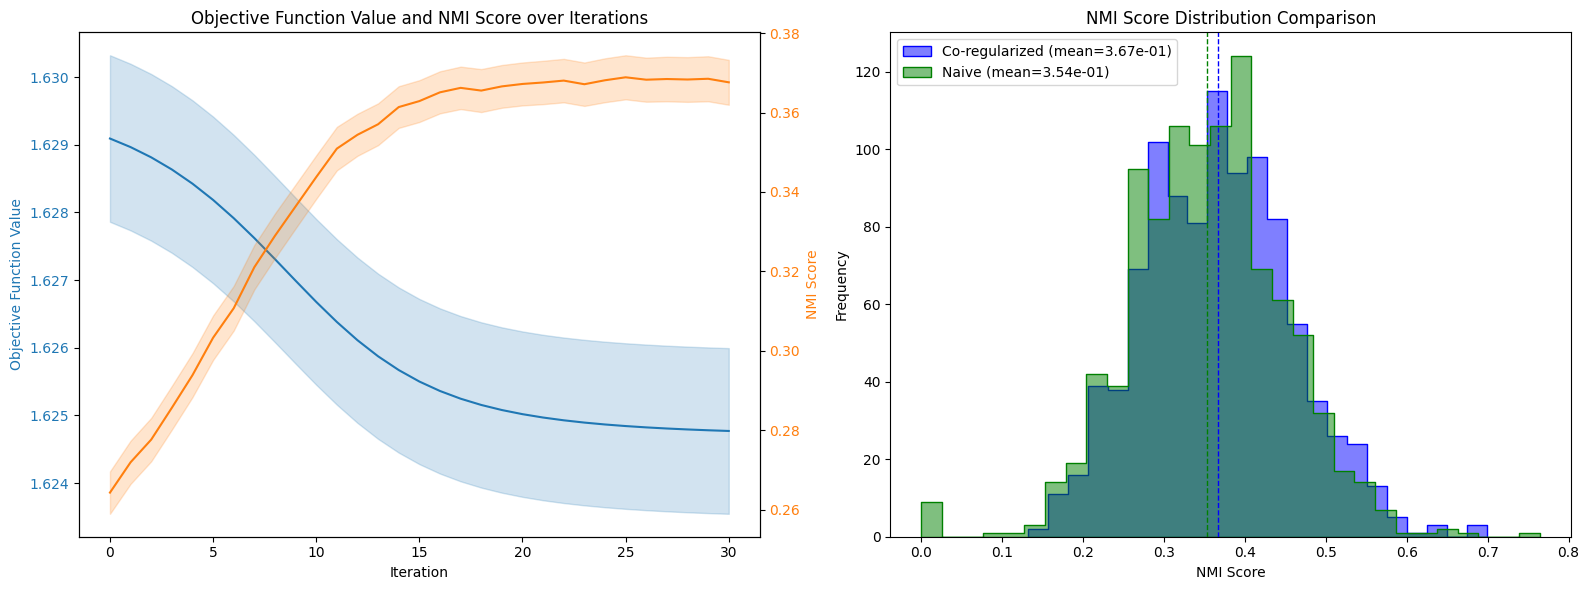

In [560]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load data
with open('multi_view.pkl', 'rb') as f:
    data = pickle.load(f)

# Convert lists to DataFrame for easier calculation
vals_df = pd.DataFrame(data['vals'])
nmi_scores_U_df = pd.DataFrame(data['nmi_scores_U'])

# Drop NaN values
vals_df.dropna(axis='columns', inplace=True)
nmi_scores_U_df.dropna(axis='columns', inplace=True)

# Number of experiments
num_experiments = vals_df.shape[0]

# Calculate mean and confidence interval
mean_vals = vals_df.mean()
std_vals = vals_df.std()
mean_nmi_scores_U = nmi_scores_U_df.mean()
std_nmi_scores_U = nmi_scores_U_df.std()

# Confidence interval (assuming normal distribution)
ci_vals = 1.96 * std_vals / np.sqrt(num_experiments)
ci_nmi_scores_U = 1.96 * std_nmi_scores_U / np.sqrt(num_experiments)

# Create subplots
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Objective Function Value and NMI Score over Iterations
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Objective Function Value', color='tab:blue')
ax1.plot(mean_vals, color='tab:blue', label='Objective Function Value')
ax1.fill_between(range(len(mean_vals)), mean_vals - ci_vals, mean_vals + ci_vals, color='tab:blue', alpha=0.2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('NMI Score', color='tab:orange')
ax2.plot(mean_nmi_scores_U, color='tab:orange', label='NMI Score')
ax2.fill_between(range(len(mean_nmi_scores_U)), mean_nmi_scores_U - ci_nmi_scores_U, mean_nmi_scores_U + ci_nmi_scores_U, color='tab:orange', alpha=0.2)
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Objective Function Value and NMI Score over Iterations')

# Plotting the histograms
final_nmi_scores_U = [scores[-1] for scores in data['nmi_scores_U']]
final_nmi_scores_naive = data['nmi_scores_naive']  # nmi_scores_naive directly is the final values list

# Calculate the mean of each NMI score set
mean_nmi_U = np.mean(final_nmi_scores_U)
mean_nmi_naive = np.mean(final_nmi_scores_naive)

# Convert means to scientific notation with two decimal places
mean_nmi_U_sci = "{:.2e}".format(mean_nmi_U)
mean_nmi_naive_sci = "{:.2e}".format(mean_nmi_naive)

# Plotting the histograms
sns.histplot(final_nmi_scores_U, kde=False, element='step', color='blue', label=f'Co-regularized (mean={mean_nmi_U_sci})', alpha=0.5, ax=ax3)
sns.histplot(final_nmi_scores_naive, kde=False, element='step', color='green', label=f'Naive (mean={mean_nmi_naive_sci})', alpha=0.5, ax=ax3)

# Plotting the mean lines
ax3.axvline(mean_nmi_U, color='blue', linestyle='dashed', linewidth=1)
ax3.axvline(mean_nmi_naive, color='green', linestyle='dashed', linewidth=1)

# Adding labels and title
ax3.set_xlabel('NMI Score')
ax3.set_ylabel('Frequency')
ax3.set_title('NMI Score Distribution Comparison')
ax3.legend(loc='upper left')

# Adjust layout and show plot
plt.tight_layout()
plt.savefig('fig/multi_view.eps')


# comparison in hybrid qubo

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


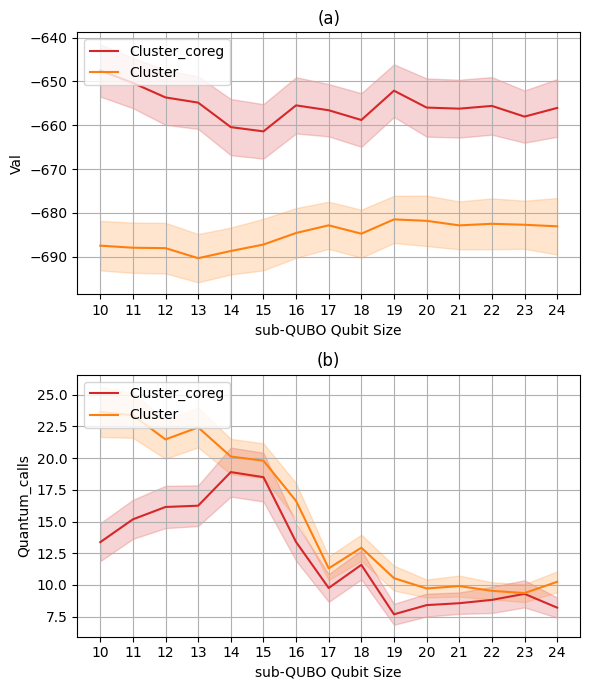

In [561]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def load_data(filename):
    with open(filename, 'rb') as file:
        return pickle.load(file)

# Load data from both files
data_list = load_data('100Node3Regular_d_data.pkl')
# data_list_large = load_data('100Nodes3Regular_d_data_large_qubit_size.pkl')

# Concatenate data lists
# data_list = data_list_small + data_list_large

# Set the full range of qubit sizes and other parameters
qubit_sizes = range(10, 25)  # From smallest in data_list_small to largest in data_list_large
metrics = ['val', 'quantum_calls', 'total_iters']
# method_names = ['impact', 'cluster', 'cluster_coreg', 'random', 'pool']
method_names = ['cluster_coreg', 'cluster']

# Create a dictionary to hold the data for plotting
plot_data = {metric: {method: {qubit_size: [] for qubit_size in qubit_sizes} for method in method_names} for metric in metrics}

# Fill the dictionary with data
for entry in data_list:
    for qubit_size in qubit_sizes:
        for metric in metrics:
            for method in method_names:
                if qubit_size in entry[f'results_{method}']:
                    plot_data[metric][method][qubit_size].append(entry[f'results_{method}'][qubit_size][metric])

def create_subplot(metric, plot_data, subplot_index, ax):
    qubit_sizes_array = np.array(list(qubit_sizes))

    for method_index, method in enumerate(method_names):
        means = [np.mean(plot_data[metric][method][qs]) if plot_data[metric][method][qs] else np.nan for qs in qubit_sizes]
        stds = [np.std(plot_data[metric][method][qs]) if plot_data[metric][method][qs] else np.nan for qs in qubit_sizes]
        sems = [stds[i] / np.sqrt(len(plot_data[metric][method][qs])) if plot_data[metric][method][qs] else np.nan for i, qs in enumerate(qubit_sizes)]

        color_index = method_index if method != 'cluster_coreg' else 3
        ax.plot(qubit_sizes_array, means, label=method.capitalize(), color=f'C{color_index}')
        ax.fill_between(qubit_sizes_array, np.array(means) - 1.96 * np.array(sems), np.array(means) + 1.96 * np.array(sems), color=f'C{color_index}', alpha=0.2)

    ax.set_title('('+f'{chr(96 + subplot_index)}'+')')
    ax.set_xlabel('sub-QUBO Qubit Size')
    ax.set_ylabel(metric.capitalize())
    ax.set_xticks(list(qubit_sizes))
    ax.legend(loc='upper left')
    ax.grid(True)

# Create figure with subplots
fig, axs = plt.subplots(2, 1, figsize=(6, 7))  # Create 2 subplots vertically
create_subplot('val', plot_data, 1, axs[0])
create_subplot('quantum_calls', plot_data, 2, axs[1])
plt.tight_layout()
plt.savefig('fig/multi-view_comparison.eps')